# Laser from longitudinal and transverse profile

Following tutorial would be an excellent example of the practical capabalities and ease of use of LASY. In this tutorial we would try to reconstruct a laser pulse for its longitudinal and transverse profile after further denoising of the later.  

In [22]:
# For VS code
%matplotlib inline
# For jupyter notbook use "%matplotlib ipympl"

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backends is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


[scikit-image](https://scikit-image.org) is required for the image processing, as the inpute data file for transverse modes is a png. Running the command below will install the package through conda. 

In [23]:
#%conda install -c conda-forge -y scikit-image 

Now lets load all the required packages for the tutorial. Which would include packages for both laser manipulation and to produce a final grapical output.

In [24]:
# Required LASY Libraries
from lasy.profiles.longitudinal import LongitudinalProfileFromData
from lasy.profiles.transverse import TransverseProfileFromData
from lasy.utils.mode_decomposition import hermite_gauss_decomposition
from lasy.profiles.combined_profile import CombinedLongitudinalTransverseProfile
from lasy.profiles.transverse.hermite_gaussian_profile import HermiteGaussianTransverseProfile
from lasy.laser import Laser
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Standard Libraries
import matplotlib.pyplot as plt
import numpy as np
import skimage 

Next, let's define the physical parameters defining our laser pulse. 

In [25]:
wavelength     = 815e-9  # Laser wavelength in meters
polarization   = (1, 0)  # Linearly polarized in the x direction
energy_J       = 1       # Pulse energy in Joules

## Reconstruct the longitudinal profile

Here as a input file we would be using data recorded using [Frequency-resolved optical gating(FROG)](https://en.wikipedia.org/wiki/Frequency-resolved_optical_gating) techinique. This would provide us with the spectral phase, intensity and time data which would be vital for our reconstruction.

In [26]:
df_intensity = np.loadtxt("https://github.com/user-attachments/files/16963766/df_intensity.csv", delimiter="\t")
filename     = 'df_intensity.csv'
             
time_s       = np.loadtxt(filename, usecols=0,  dtype='float') 
Et_Re        = np.loadtxt(filename, usecols=1,  dtype='float') 
Et_Im        = np.loadtxt(filename, usecols=2,  dtype='float') 
Et_complex   = Et_Re + 1j * Et_Im

# retrieve Intensity and Phase
Et_intensity = np.abs(Et_complex)**2
Et_phase     = np.arctan(Et_Im, Et_Re)

# shift to peak intensity at t=0
peak_index   = np.argmax(Et_intensity)
time_s      -= time_s[peak_index]

In [27]:
fs                  = 1e-15 # femtoseconds
longitudinal_data   = {
    "datatype":   "temporal",
    "axis":       time_s.flatten(),
    "intensity":  Et_intensity.flatten(),
    "phase":      Et_phase.flatten(),
    "wavelength": wavelength
}

longitudinal_profile = LongitudinalProfileFromData(
    longitudinal_data,
    lo=-200 * fs,
    hi=200 * fs
)


## Transverse Mode

In [28]:
# Define the transverse profile of the laser pulse
img           = "https://user-images.githubusercontent.com/27694869/228038930-d6ab03b1-a726-4b41-a378-5f4a83dc3778.png"
intensityData = skimage.io.imread(img)

# data cleaning: remove negative values
intensityData[intensityData < 2.1] = 0

In [29]:
cal             = 0.1e-6 
# axes
rows,cols       = intensityData.shape
transverse_x_mu = np.linspace(0,cols-1,cols)*cal  #This scale factor comes from a rough estimate
transverse_y_mu = np.linspace(0,rows-1,rows)*cal  #This scale factor comes from a rough estimate
lo = (transverse_x_mu[0], transverse_y_mu[0])
hi = (transverse_x_mu[-1], transverse_y_mu[-1])

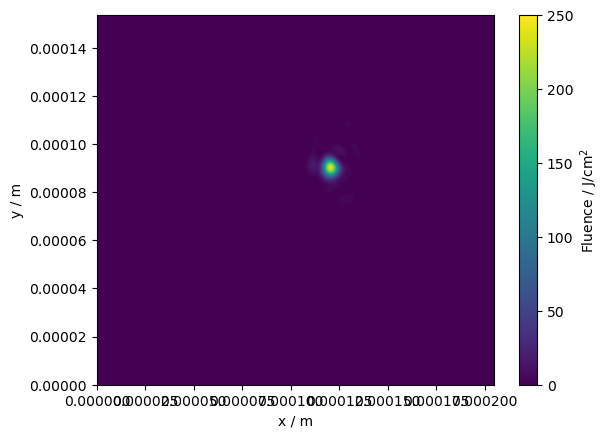

In [30]:
from lasy.profiles.transverse import transverse_profile


fig,ax = plt.subplots()

cax = ax.imshow(
    intensityData,
    aspect="auto",
    extent=[
        lo[0], hi[0],
        lo[1], hi[1]
    ],
)

# Add a colorbar
color_bar = fig.colorbar(cax)

# Add a label to the colorbar
color_bar.set_label(r"Fluence / J/cm$^2$")
# ax.set_xlabel(r"x / $\mu$m")
# ax.set_ylabel(r"y / $\mu$m")
ax.set_xlabel(r"x / m")
ax.set_ylabel(r"y / m")
plt.show()

In [31]:

transverse_profile = TransverseProfileFromData(
    intensityData,
    [lo[0] , lo[1]],
    [hi[0] , hi[1]]
)

# Transversal Profile Denoising
See https://github.com/LASY-org/lasy/blob/13f0e4515493deca36c1375be1d9e83c7e379d42/examples/example_modal_decomposition_data.py

In [70]:
# Calculate the decomposition into hermite-gauss modes
n_x_max           = 2
n_y_max           = 2
modeCoeffs, waist = hermite_gauss_decomposition(
    transverse_profile, n_x_max=n_x_max, n_y_max=n_y_max, res=cal
)



Estimated w0 = 6.89 microns
{(0, 0): 0.9620098611239595, (0, 1): 0.013948559092897602, (1, 0): 0.024547426421505463, (1, 1): 0.031532255433053276}


## Combine

In [71]:
# original transverse data
org_laser_profile = CombinedLongitudinalTransverseProfile(
    wavelength    = wavelength,
    pol           = polarization,
    laser_energy  = energy_J,
    long_profile  = longitudinal_profile,
    trans_profile = transverse_profile
)

In [72]:
# denoised transverse data
# Reconstruct the pulse using a series of hermite-gauss modes
for i, mode_key in enumerate(list(modeCoeffs)):
    tmp_transverse_profile = HermiteGaussianTransverseProfile(
        waist, mode_key[0], mode_key[1]
    )
    if i == 0:
        laser_profile = modeCoeffs[
            mode_key
        ] * CombinedLongitudinalTransverseProfile(
            wavelength, polarization, energy_J, longitudinal_profile, tmp_transverse_profile
        )
    else:
        laser_profile += modeCoeffs[
            mode_key
        ] * CombinedLongitudinalTransverseProfile(
            wavelength, polarization, energy_J, longitudinal_profile, tmp_transverse_profile
        )

## Plot Denoised Profile

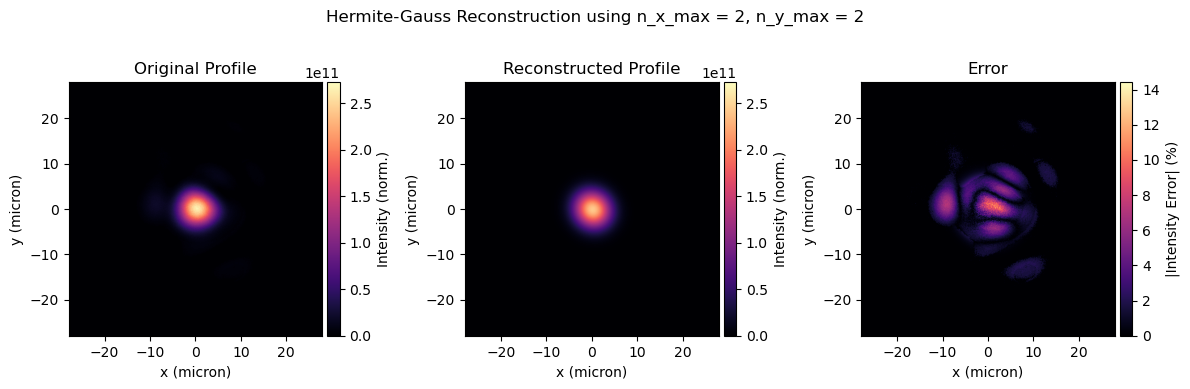

In [73]:
# Plotting the results
x = np.linspace(-5 * waist, 5 * waist, 500)
X, Y = np.meshgrid(x, x)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)

pltextent = (np.min(x) * 1e6, np.max(x) * 1e6, np.min(x) * 1e6, np.max(x) * 1e6)
prof1 = np.abs(org_laser_profile.evaluate(X, Y, 0)) ** 2
divider0 = make_axes_locatable(ax[0])
ax0_cb = divider0.append_axes("right", size="5%", pad=0.05)
pl0 = ax[0].imshow(prof1, cmap="magma", extent=pltextent, vmin=0, vmax=np.max(prof1))
cbar0 = fig.colorbar(pl0, cax=ax0_cb)
cbar0.set_label("Intensity (norm.)")
ax[0].set_xlabel("x (micron)")
ax[0].set_ylabel("y (micron)")
ax[0].set_title("Original Profile")

prof2 = np.abs(laser_profile.evaluate(X, Y, 0)) ** 2
divider1 = make_axes_locatable(ax[1])
ax1_cb = divider1.append_axes("right", size="5%", pad=0.05)
pl1 = ax[1].imshow(prof2, cmap="magma", extent=pltextent, vmin=0, vmax=np.max(prof1))
cbar1 = fig.colorbar(pl1, cax=ax1_cb)
cbar1.set_label("Intensity (norm.)")
ax[1].set_xlabel("x (micron)")
ax[1].set_ylabel("y (micron)")
ax[1].set_title("Reconstructed Profile")


prof3 = (prof1 - prof2) / np.max(prof1)
divider2 = make_axes_locatable(ax[2])
ax2_cb = divider2.append_axes("right", size="5%", pad=0.05)
pl2 = ax[2].imshow(100 * np.abs(prof3), cmap="magma", extent=pltextent)
cbar2 = fig.colorbar(pl2, cax=ax2_cb)
cbar2.set_label("|Intensity Error| (%)")
ax[2].set_xlabel("x (micron)")
ax[2].set_ylabel("y (micron)")
ax[2].set_title("Error")

fig.suptitle(
    "Hermite-Gauss Reconstruction using n_x_max = %i, n_y_max = %i" % (n_x_max, n_y_max)
)
plt.show()

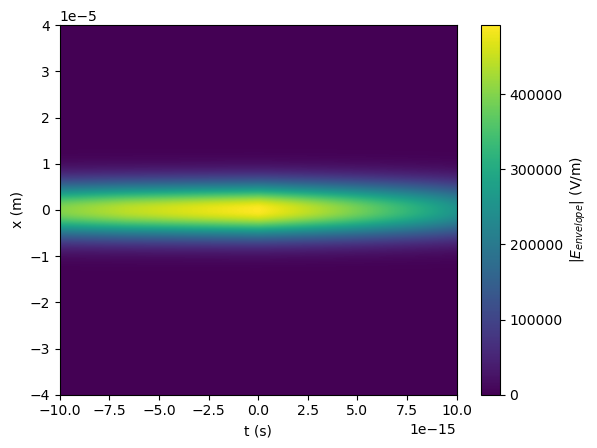

In [74]:
	
dimensions = "rt"  # Use cylindrical geometry
lo = (0, -1e-14)  # Lower bounds of the simulation box
hi = (40e-6,1e-14)  # Upper bounds of the simulation box
num_points = (3000, 500)  # Number of points in each dimension

# laser = Laser(dimensions, lo, hi, num_points, laser_profile.evaluate(X, Y, 0))
# laser.show()

laser = Laser(dimensions,lo,hi,num_points,laser_profile)
laser.show()

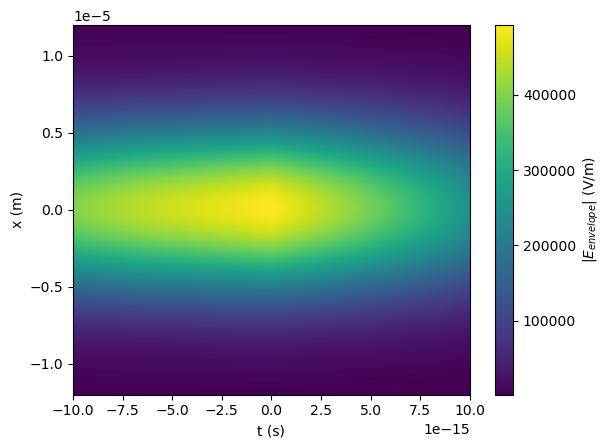

In [81]:
pulse_duration = 1e-14
dimensions     = "xyt"                               # Use 3D geometry
lo             = (-12.0e-6, -12.0e-6, -1*pulse_duration)           # Lower bounds of the simulation box
hi             = ( 12.0e-6,  12.0e-6, 1*pulse_duration)  # Upper bounds of the simulation box
#lo             = (transverse_x_mu[0] , transverse_y_mu[0] , -7*pulse_duration)           # Lower bounds of the simulation box
#hi             = (transverse_x_mu[-1], transverse_y_mu[-1], 10*pulse_duration)  # Upper bounds of the simulation box
num_points     = (300, 300, 500)                     # Number of points in each dimension
#num_points     = (50, 50, 200)                     # low res for quick tests

laser_xyt = Laser(dimensions, lo, hi, num_points, laser_profile)
laser_xyt.show()

In [53]:
pulse_duration = 50e-15
spot_size = 15e-6
dimensions     = "rt"                               # Use 3D geometry
lo             = (0, -7*pulse_duration)           # Lower bounds of the simulation box
hi             = (5*spot_size, 10*pulse_duration)  # Upper bounds of the simulation box
num_points     = (300, 500)                     # Number of points in each dimension

laser_rt_org = Laser(dimensions, lo, hi, num_points, org_laser_profile)

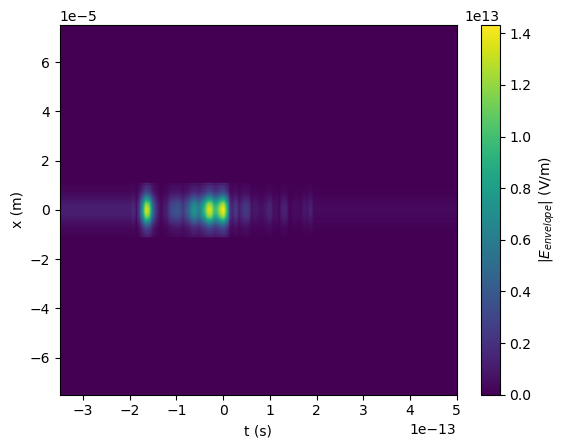

In [54]:
plt.figure()
laser_rt_org.show()

In [39]:
dimensions     = "rt"                               # Use 3D geometry
lo             = (0, -7*pulse_duration)           # Lower bounds of the simulation box
hi             = (5*spot_size, 10*pulse_duration)  # Upper bounds of the simulation box
num_points     = (300, 500)                     # Number of points in each dimension

# hack: add laser_energy attribute
laser_profile.laser_energy = energy_J

laser_rt = Laser(dimensions, lo, hi, num_points, laser_profile)

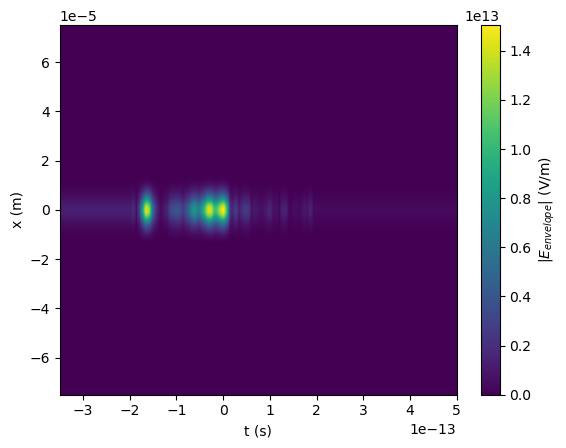

In [40]:
plt.figure()
laser_rt.show()

### XYT

In [41]:
dimensions     = "xyt"                               # Use 3D geometry
lo             = (-12.0e-6, -12.0e-6, -7*pulse_duration)           # Lower bounds of the simulation box
hi             = ( 12.0e-6,  12.0e-6, 10*pulse_duration)  # Upper bounds of the simulation box
#lo             = (transverse_x_mu[0] *mu, transverse_y_mu[0] *mu, -7*pulse_duration)           # Lower bounds of the simulation box
#hi             = (transverse_x_mu[-1]*mu, transverse_y_mu[-1]*mu, 10*pulse_duration)  # Upper bounds of the simulation box
num_points     = (300, 300, 500)                     # Number of points in each dimension
#num_points     = (50, 50, 200)                     # low res for quick tests

laser_xyt = Laser(dimensions, lo, hi, num_points, laser_profile)

KeyboardInterrupt: 

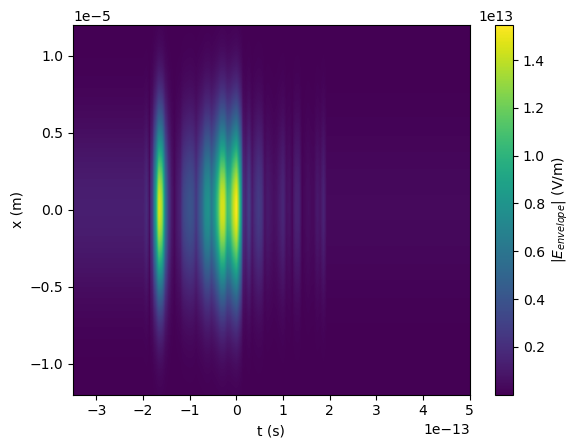

In [ ]:
plt.figure()
laser_xyt.show()

# Propagate Backwards from Focus for Initialization in Simulation

In [ ]:
profile_focal_distance = 24.0e-6
laser_xyt.propagate(-profile_focal_distance)  # Propagate the pulse upstream of the focal plane

/opt/anaconda3/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/anaconda3/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/anaconda3/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),
/opt/anaconda3/lib/python3.12/ast.py:587: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)


NameError: name 'laser_xyt' is not defined

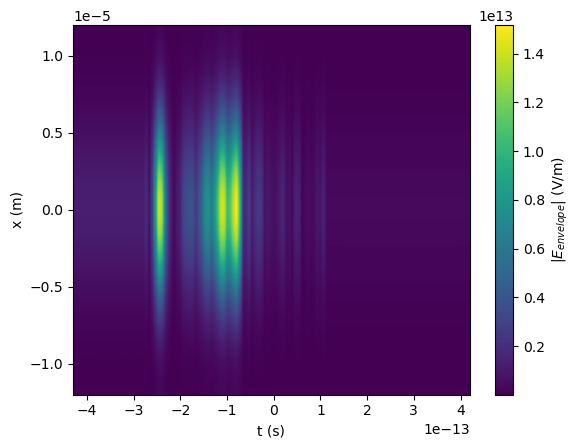

In [ ]:
plt.figure()
laser_xyt.show()

In [ ]:
file_prefix    = "BELLAiP2_24J_24um_to_focus"

laser_xyt.write_to_file(file_prefix, file_format="h5")